In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('/Users/mark/git/swifd')
from swifd import SwiModel

plt.rcParams['figure.figsize'] = (4, 3)
plt.rcParams['font.size'] = 8
plt.rcParams["figure.autolayout"] = True # same as tight_layout after every plot

### Single fluid case
Model of one cell, five layers, inflow at the top for 10 time steps followed by outflow for 10 time steps. Top layer is unconfined and during the outflow head (and thus phreatic surface) drops below top of the aquifer.

In [2]:
nlay = 5
ncol = 1
delx = 1.0
k = 5 * np.ones(nlay)
S = 0.1 * np.ones(nlay)
Se = 1e-6 * np.ones(nlay)
z = np.linspace(0, -nlay, nlay + 1)
zt = z[:-1]
zb = z[1:]
N = 0.1
Qfin = [[0, 0, N * delx]]
Qfout = [[0, 0, -N * delx]]
fixedf = []
fixeds = [[nlay - 1, 0, 0]]
rhof = 1000
rhos = 1025
hfini = 0.0125 * np.ones((nlay, ncol))
hsini = np.zeros((nlay, ncol))
#
nstep = 10
delt = 0.2

In [3]:
ml = SwiModel(nlay, ncol, delx) # model for inflow
ml.tdis(nstep, delt, hfini, hsini)
ml.aquifer(k, S, Se, zb, zt, rhof, rhos)
ml.set_source(Qf=Qfin)
ml.set_fixed(fixeds=fixeds)
hfsol1, zetasol1 = ml.simulate_freshonly(silent=False)
#
ml = SwiModel(nlay, ncol, delx) # modelf for outflow
ml.tdis(nstep, delt, hfini=hfsol1[-1], hsini=hsini)
ml.aquifer(k, S, Se, zb, zt, rhof, rhos)
ml.set_source(Qf=Qfout)
ml.set_fixed(fixeds=fixeds)
hfsol2, zetasol2 = ml.simulate_freshonly(silent=False)

iterations: 2
iterations: 2
iterations: 3
iterations: 2
iterations: 2
iterations: 2
iterations: 2
iterations: 3
iterations: 2
iterations: 2
iterations: 4
iterations: 2
iterations: 3
iterations: 2
iterations: 3
iterations: 2
iterations: 2
iterations: 2
iterations: 2
iterations: 3


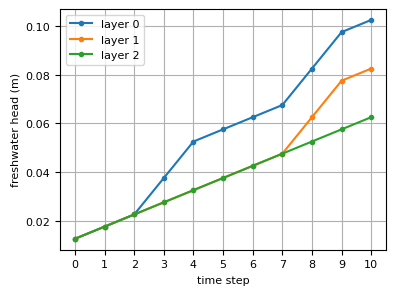

In [4]:
plt.plot(hfsol1[:, 0, 0], marker='.', label='layer 0')
plt.plot(hfsol1[:, 1, 0], marker='.', label='layer 1')
plt.plot(hfsol1[:, 2, 0], marker='.', label='layer 2')
plt.xticks(np.arange(11))
plt.xlabel('time step')
plt.ylabel('freshwater head (m)')
plt.legend()
plt.grid()

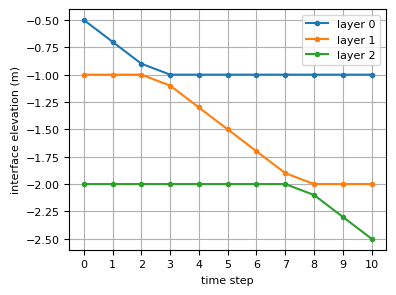

In [5]:
plt.plot(zetasol1[:, 0, 0], marker='.', label='layer 0')
plt.plot(zetasol1[:, 1, 0], marker='.', label='layer 1')
plt.plot(zetasol1[:, 2, 0], marker='.', label='layer 2')
plt.xticks(np.arange(11))
plt.xlabel('time step')
plt.ylabel('interface elevation (m)')
plt.legend()
plt.grid()

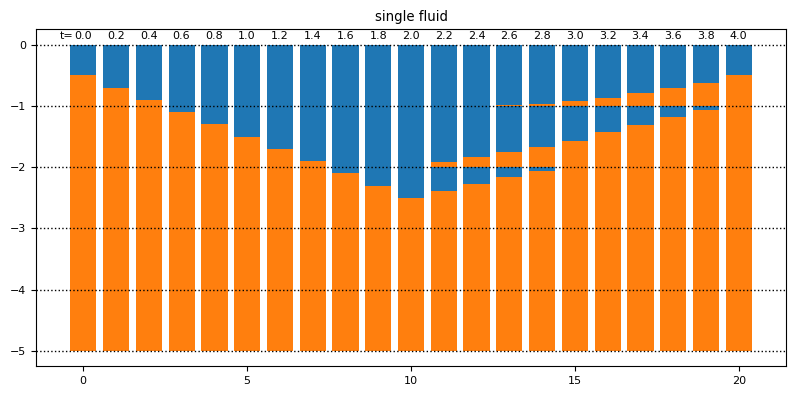

In [6]:
def plotzeta(zeta, x=0, delx=1):
    for i in range(nlay):
        plt.fill([x - delx / 2, x + delx / 2, x + delx / 2, x - delx / 2], [zeta[i], zeta[i], zt[i], zt[i]], 'C0')
        plt.fill([x - delx / 2, x + delx / 2, x + delx / 2, x - delx / 2], [zb[i], zb[i], zeta[i], zeta[i]], 'C1')

plt.figure(figsize=(8, 4))
x = np.arange(21)
for i in range(nstep + 1):
    plotzeta(zetasol1[i].squeeze(), x[i], delx=0.8)
for i in range(1, nstep + 1):
    plotzeta(zetasol2[i].squeeze(), x[i] + 10, delx=0.8)
for i in range(len(z)):
    plt.axhline(z[i], color='k', linestyle=':', linewidth=1)
plt.text(-0.5, 0.1, 't=', ha='center')
for i in range(2 * nstep + 1):
    plt.text(x[i], 0.1, f'{i * delt:.1f}', ha='center')
plt.title('single fluid');

### Two-fluid case
Model of one cell, five layers, inflow at the top for 10 time steps followed by outflow for 10 time steps. Top layer is unconfined and during the outflow head (and thus phreatic surface) drops below top of the aquifer.

In [7]:
ml = SwiModel(nlay, ncol, delx)
ml.tdis(nstep, delt, hfini, hsini)
ml.aquifer(k, S, Se, zb, zt, rhof, rhos)
ml.set_source(Qf=Qfin)
ml.set_fixed(fixeds=fixeds)
hfsol3, hssol3, zetasol3 = ml.simulate(silent=False)
#
ml2 = SwiModel(nlay, ncol, delx)
ml2.tdis(2 * nstep, delt=delt / 2, hfini=hfsol3[-1], hsini=hssol3[-1]) # time step is halved
ml2.aquifer(k, S, Se, zb, zt, rhof, rhos)
ml2.set_source(Qf=Qfout)
ml2.set_fixed(fixeds=fixeds)
hfsol4, hssol4, zetasol4 = ml2.simulate(silent=False, htol=1e-6)

iterations: 4
iterations: 1
iterations: 4
iterations: 3
iterations: 1
iterations: 1
iterations: 1
iterations: 4
iterations: 3
iterations: 1
iterations: 3
iterations: 1
iterations: 2
iterations: 1
iterations: 2
iterations: 3
iterations: 1
iterations: 3
iterations: 1
iterations: 2
iterations: 2
iterations: 1
iterations: 2
iterations: 1
iterations: 2
iterations: 3
iterations: 1
iterations: 1
iterations: 1
iterations: 1


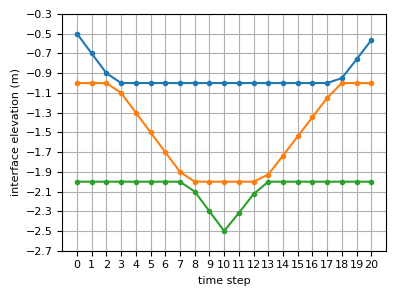

In [8]:
plt.plot(np.hstack((zetasol3[:, 0, 0], zetasol4[2::2, 0, 0])), marker='.')
plt.plot(np.hstack((zetasol3[:, 1, 0], zetasol4[2::2, 1, 0])), marker='.')
plt.plot(np.hstack((zetasol3[:, 2, 0], zetasol4[2::2, 2, 0])), marker='.')
plt.xticks(np.arange(0, 2 * nstep + 1))
plt.yticks(np.arange(-2.7, -0.3, 0.2))
plt.xlabel('time step')
plt.ylabel('interface elevation (m)')
plt.grid()

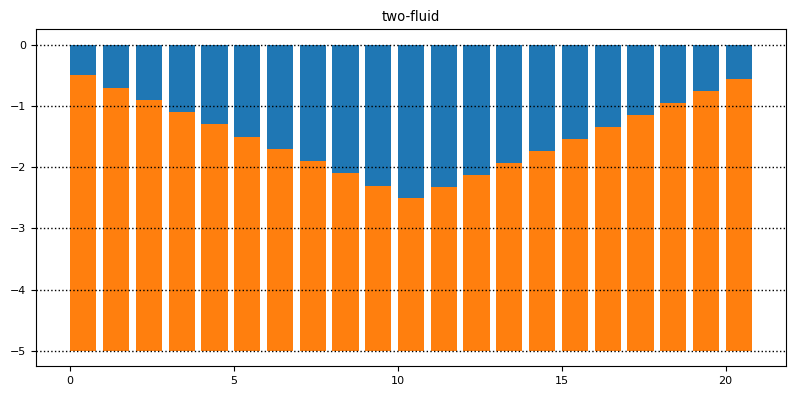

In [9]:
def plotzeta(zeta, x=0, delx=1):
    for i in range(nlay):
        plt.fill([x, x + delx, x + delx, x], [zeta[i], zeta[i], zt[i], zt[i]], 'C0')
        plt.fill([x, x + delx, x + delx, x], [zb[i], zb[i], zeta[i], zeta[i]], 'C1')

plt.figure(figsize=(8, 4))
x = np.arange(21)
for i in range(nstep + 1):
    plotzeta(zetasol3[i].squeeze(), x[i], delx=0.8)
for i in range(2, 2 * nstep + 1, 2):
    plotzeta(zetasol4[i].squeeze(), x[i] / 2 + 10, delx=0.8)
for i in range(len(z)):
    plt.axhline(z[i], color='k', linestyle=':', linewidth=1)
plt.title('two-fluid');